## ✈️ Flight Price Prediction Project

In [22]:
#step1:Importing the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
#step2:Loading the dataset
df=pd.read_excel('Data_Train.xlsx')
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [24]:
# step3: Data Preprocessing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [25]:
# change the date of journey column to datetime format
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'],format='%d/%m/%Y')
df['Date_of_Journey'].head()

0   2019-03-24
1   2019-05-01
2   2019-06-09
3   2019-05-12
4   2019-03-01
Name: Date_of_Journey, dtype: datetime64[ns]

In [26]:
# extract day , month and year from date of journey column
df['day'] = df['Date_of_Journey'].dt.day
df['month'] = df['Date_of_Journey'].dt.month
df['year'] = df['Date_of_Journey'].dt.year

In [27]:
#drop date of journey column
df.drop('Date_of_Journey',axis=1,inplace=True)

In [28]:
#extract the dep_hour and dep_minute from the dep_time using the split functiom
df['Dep_Hour']=df['Dep_Time'].str.split(':').str[0].astype(int)
df['Dep_Minute']=df['Dep_Time'].str.split(':').str[1].astype(int)


In [29]:
#drop the dep time column
df.drop('Dep_Time',axis=1,inplace=True)

In [30]:
# extract time and date from arrival time column
df['Arrival_Time'] = df['Arrival_Time'].str.split(' ').str[0]
df['Arrival_Hour'] = df['Arrival_Time'].str.split(':').str[0].astype(int)
df['Arrival_Minute'] = df['Arrival_Time'].str.split(':').str[1].astype(int)
df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,day,month,year,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25,19h,2 stops,No info,13882,9,6,2019,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35


In [32]:
# extract duration hour and duration minute from duration column without characters
df['Duration_Hour'] = df['Duration'].str.split(' ').str[0].str.replace('h','')
df['Duration_Minute'] = df['Duration'].str.split(' ').str[1].str.replace('m','')
df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,day,month,year,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Hour,Duration_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25,19h,2 stops,No info,13882,9,6,2019,9,25,4,25,19,NaN
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35,4,45


In [33]:
df.drop(['Arrival_Time','Duration'],axis=1,inplace=True)

In [34]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,day,month,year,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Hour,Duration_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,2019,9,25,4,25,19,NaN
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,2019,16,50,21,35,4,45


In [35]:
df['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [36]:
map={'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4}
df['Total_Stops']=df['Total_Stops'].map(map)

In [37]:
df

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,day,month,year,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Hour,Duration_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,0.0,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2.0,No info,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2.0,No info,13882,9,6,2019,9,25,4,25,19,NaN
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1.0,No info,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1.0,No info,13302,1,3,2019,16,50,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,0.0,No info,4107,9,4,2019,19,55,22,25,2,30
10679,Air India,Kolkata,Banglore,CCU → BLR,0.0,No info,4145,27,4,2019,20,45,23,20,2,35
10680,Jet Airways,Banglore,Delhi,BLR → DEL,0.0,No info,7229,27,4,2019,8,20,11,20,3,NaN
10681,Vistara,Banglore,New Delhi,BLR → DEL,0.0,No info,12648,1,3,2019,11,30,14,10,2,40


In [38]:
df['Route'].value_counts()

Route
DEL → BOM → COK          2376
BLR → DEL                1552
CCU → BOM → BLR           979
CCU → BLR                 724
BOM → HYD                 621
                         ... 
CCU → VTZ → BLR             1
CCU → IXZ → MAA → BLR       1
BOM → COK → MAA → HYD       1
BOM → CCU → HYD             1
BOM → BBI → HYD             1
Name: count, Length: 128, dtype: int64

In [39]:
#create a new column for route1 ,route 2,route 3, route 4, route 5
df['Route_1']=df['Route'].str.split('→').str[0]
df['Route_2']=df['Route'].str.split('→').str[1]
df['Route_3']=df['Route'].str.split('→').str[2]
df['Route_4']=df['Route'].str.split('→').str[3]
df['Route_5']=df['Route'].str.split('→').str[4]

In [41]:
df.head()


,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,day,month,year,...,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Hour,Duration_Minute,Route_1,Route_2,Route_3,Route_4,Route_5
0,IndiGo,Banglore,New Delhi,BLR → DEL,0.0,No info,3897,24,3,2019,...,20,1,10,2,50,BLR,DEL,NaN,NaN,NaN
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2.0,No info,7662,1,5,2019,...,50,13,15,7,25,CCU,IXR,BBI,BLR,NaN
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2.0,No info,13882,9,6,2019,...,25,4,25,19,NaN,DEL,LKO,BOM,COK,NaN
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1.0,No info,6218,12,5,2019,...,5,23,30,5,25,CCU,NAG,BLR,NaN,NaN
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1.0,No info,13302,1,3,2019,...,50,21,35,4,45,BLR,NAG,DEL,NaN,NaN


In [ ]:
df['Route_1'].fillna('None', inplace=True)
df['Route_2'].fillna('None', inplace=True)
df['Route_3'].fillna('None', inplace=True)
df['Route_4'].fillna('None', inplace=True)
df['Route_5'].fillna('None', inplace=True)

In [45]:
df.head()


,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,day,month,year,...,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Hour,Duration_Minute,Route_1,Route_2,Route_3,Route_4,Route_5
0,IndiGo,Banglore,New Delhi,BLR → DEL,0.0,No info,3897,24,3,2019,...,20,1,10,2,50,BLR,DEL,None,None,None
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2.0,No info,7662,1,5,2019,...,50,13,15,7,25,CCU,IXR,BBI,BLR,None
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2.0,No info,13882,9,6,2019,...,25,4,25,19,NaN,DEL,LKO,BOM,COK,None
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1.0,No info,6218,12,5,2019,...,5,23,30,5,25,CCU,NAG,BLR,None,None
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1.0,No info,13302,1,3,2019,...,50,21,35,4,45,BLR,NAG,DEL,None,None


In [46]:
df.drop('Route',axis=1,inplace=True)

## EDA

<Axes: xlabel='Source', ylabel='Price'>

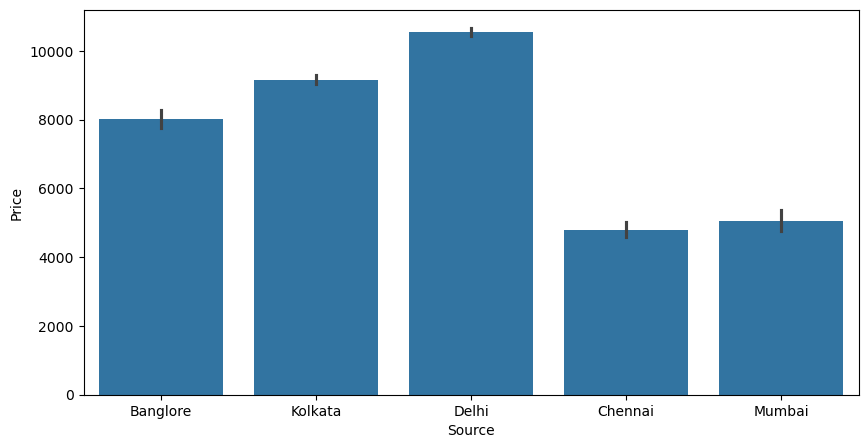

In [ ]:

plt.figure(figsize=(10,5))
sns.barplot(x='Source',y='Price',data=df)


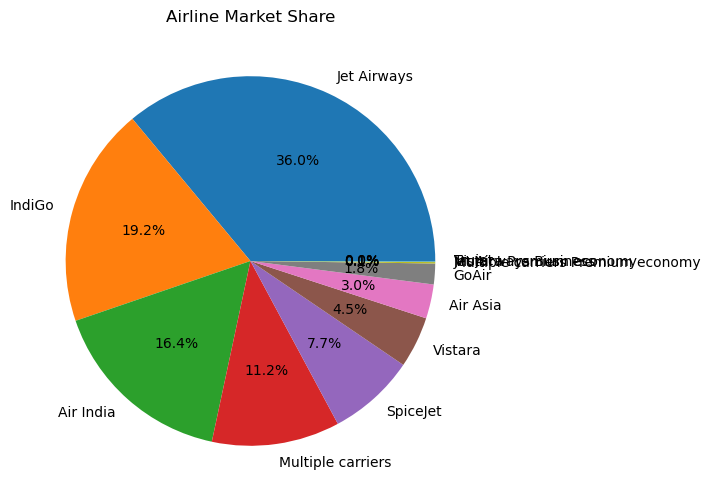

In [53]:
plt.figure(figsize=(6,6))
df['Airline'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Airline Market Share")
plt.ylabel('')
plt.show()

In [54]:
# step5: Feature Engineering
#handled categorical data using label encoding
from sklearn.preprocessing import LabelEncoder
# create an instance for label encoder
le=LabelEncoder()

#encode the airline column

df['Airline'] = le.fit_transform(df['Airline'])
df['Source'] = le.fit_transform(df['Source'])
df['Destination'] = le.fit_transform(df['Destination'])
df['Route_1'] = le.fit_transform(df['Route_1'])
df['Route_2'] = le.fit_transform(df['Route_2'])
df['Route_3'] = le.fit_transform(df['Route_3'])
df['Route_4'] = le.fit_transform(df['Route_4'])
df['Route_5'] = le.fit_transform(df['Route_5'])


In [55]:
df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,day,month,year,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Hour,Duration_Minute,Route_1,Route_2,Route_3,Route_4,Route_5
0,3,0,5,0.0,No info,3897,24,3,2019,22,20,1,10,2,50,0,13,29,13,5
1,1,3,0,2.0,No info,7662,1,5,2019,5,50,13,15,7,25,2,25,1,3,5
2,4,2,1,2.0,No info,13882,9,6,2019,9,25,4,25,19,NaN,3,32,4,5,5
3,3,3,0,1.0,No info,6218,12,5,2019,18,5,23,30,5,25,2,34,3,13,5
4,3,0,5,1.0,No info,13302,1,3,2019,16,50,21,35,4,45,0,34,8,13,5
